<a href="https://colab.research.google.com/github/Sergiopablo-rg/2015lab1/blob/master/Final_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Decline Curve Analisis


##Empirical Type Curve Solution

Arp's Rate - Time Equations

$$\frac{q(t)}{q_i} = \frac{1}{\left [ 1+bD_it \right ]^{\frac{1}{b}}}$$

For exponential decline equation $\rightarrow$ b=0
$$\frac{q(t)}{q_i} = \frac{1}{e^{D_it}} $$

For harmonic decline equation $\rightarrow$ b=1
$$\frac{q(t)}{q_i} = \frac{1}{\left [ 1+D_it \right ]} $$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#import pandas as pd

/tmp/ipykernel_2509/1698591497.py:5: RuntimeWarning: overflow encountered in exp
  q = 1/(np.exp(Di*t))


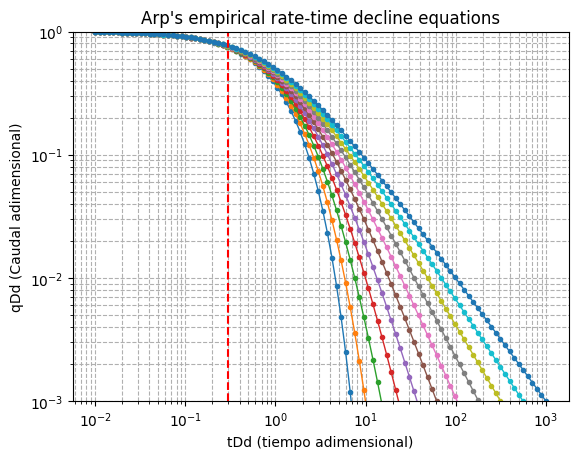

In [ ]:
#b = 0
Di = 1
t = np.logspace(-2, 3, num=100)
# Una función de prueba (por ejemplo, y = x^2)
q = 1/(np.exp(Di*t))

# Grafica para b=0
plt.plot(t, q, marker='.', linestyle='-', linewidth=1, label="b=0")
plt.xscale('log')  # <--- Esto activa la escala logarítmica en el eje X
plt.yscale('log')  # <--- Esto activa la escala logarítmica en el eje Y
plt.title("Arp's empirical rate-time decline equations")
plt.xlabel('tDd (tiempo adimensional)')
plt.ylabel('qDd (Caudal adimensional)')
plt.ylim(0.001, 1)
plt.grid(True, which="both", ls="--") # Cuadrícula para ver las divisiones logarítmicas

#Graficas para b = 0.1 -> 1
#t = np.logspace(-2, 3, num=100)
b = np.arange(0.1,1.1,0.1)
for i in b:
  q = 1/(1+(i*Di*t))**(1/i)
  plt.plot(t, q, marker='.', linestyle='-', linewidth=1, label=f"b={i:.1f}")

# Linea vertical tDd = 0.3 (tiempo adimensional)
# cualquier dato antes de 0.3 parece tener un comportamiento exponencial
# independientemente del valor de b (una linea recta en semi-log)
# un metodo estadistico podria calcular cualquier valor de b (0 -> 1)
plt.axvline(
    x=0.3,  # El punto exacto en el eje X
    color="red",  # Color de la línea
    linestyle="--",  # Estilo de la línea (discontinua/guiones)
    linewidth=1.5,  # Grosor de la línea
    label="Línea crítica (x=0.3)",  # una leyenda
)

#plt.legend()
plt.show()

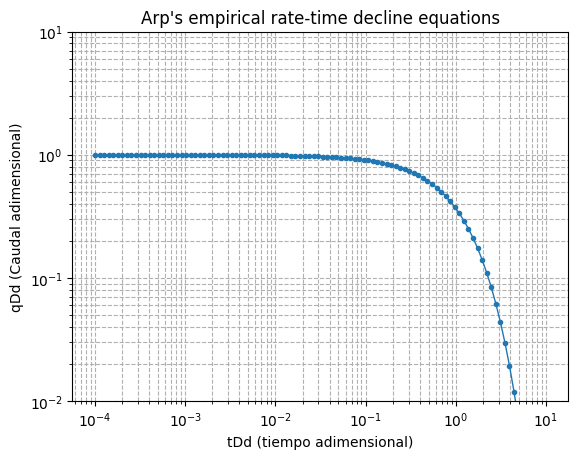

In [ ]:
#b = 0
Di = 1
t = np.logspace(-4, 1, num=100)
# Una función de prueba (por ejemplo, y = x^2)
q = (np.exp(-Di*t))

# Grafica para b=0
plt.plot(t, q, marker='.', linestyle='-', linewidth=1, label="b=0")
plt.xscale('log')  # <--- Esto activa la escala logarítmica en el eje X
plt.yscale('log')  # <--- Esto activa la escala logarítmica en el eje Y
plt.title("Arp's empirical rate-time decline equations")
plt.xlabel('tDd (tiempo adimensional)')
plt.ylabel('qDd (Caudal adimensional)')
plt.ylim(0.01, 10)
plt.grid(True, which="both", ls="--") # Cuadrícula para ver las divisiones logarítmicas



#plt.legend()
plt.show()

##Anlitical Type Curve Solution

Fetkovich Rate - Time Equations

$$q_{dD}=\frac{q(t)}{q_i} = q_D \left[\ln\frac{re}{rw}-\frac{1}{2} \right]$$

$$t_{dD}=\frac{t_D}{\frac{1}{2}\left[ (\frac{re}{rw})^2-1\right]\left[\ln\frac{re}{rw}-\frac{1}{2}\right]}$$

re_rw=10
re_rw=20
re_rw=50
re_rw=100
re_rw=200


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


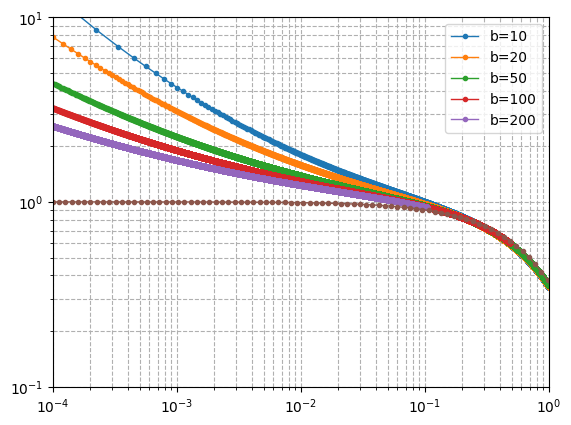

In [ ]:
# Fetkovich
a,b_1,c,d = -0.00159, 0.06517, 7.22390, 1.81387
e,f,g,h = 4.89275, 0.71374, 0.000448, 0.03622
i,j,k,l = 6.072758, 0.788941, 5.209117, 0.783041
re_rw_lst = [10,20,50,100,200]#,1000,10000,100000] #np.arange(10,100,20)
#print(re_rw)
for re_rw in re_rw_lst:
  print(f"re_rw={re_rw}")
  A0 = a+b_1/(1+c*(((np.log(re_rw)-0.5)-d)/e)**2)**f
  A1 = g+h/(1+i*(((np.log(re_rw)-0.5)-j)/k)**2)**l
  tD = np.arange(0.01,10000,0.01)
  tdD = tD/(0.5*((re_rw**2)-1)*(np.log(re_rw)-0.5))
  b = 1*10**(-8)
  qdD = (1+b*tdD)**(-1/b)*np.exp(A1*np.log(tdD)**2-A0)
  plt.plot(tdD, qdD, marker='.', linestyle='-', linewidth=1, label=f"b={re_rw}")
plt.xscale('log')  # <--- Esto activa la escala logarítmica en el eje X
plt.yscale('log')  # <--- Esto activa la escala logarítmica en el eje Y
plt.ylim(0.1, 10)
plt.xlim(0.0001, 1)
plt.grid(True, which="both", ls="--")
#print(f"tD={tD}")
#print(f"A0={A0}")
#print(f"A1={A1}")
#print(qdD)
#print(tdD)
plt.legend()
Di = 1
t = np.logspace(-4, 1, num=100)
# Una función de prueba (por ejemplo, y = x^2)
q = (np.exp(-Di*t))

# Grafica para b=0
plt.plot(t, q, marker='.', linestyle='-', linewidth=1, label="b=0")

/tmp/ipykernel_2509/4258132923.py:27: RuntimeWarning: overflow encountered in exp
  q = 1/(np.exp(Di*t))


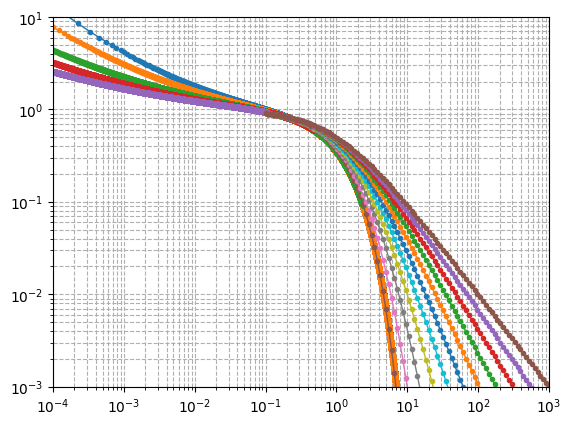

In [ ]:
# Fetkovich
a,b_1,c,d = -0.00159, 0.06517, 7.22390, 1.81387
e,f,g,h = 4.89275, 0.71374, 0.000448, 0.03622
i,j,k,l = 6.072758, 0.788941, 5.209117, 0.783041
re_rw_lst = [10,20,50,100,200]#,1000,10000,100000] #np.arange(10,100,20)
#print(re_rw)
for re_rw in re_rw_lst:
  #print(f"re_rw={re_rw}")
  A0 = a+b_1/(1+c*(((np.log(re_rw)-0.5)-d)/e)**2)**f
  A1 = g+h/(1+i*(((np.log(re_rw)-0.5)-j)/k)**2)**l
  tD = np.arange(0.01,10000,0.01)
  tdD = tD/(0.5*((re_rw**2)-1)*(np.log(re_rw)-0.5))
  b = 1*10**(-8)
  qdD = (1+b*tdD)**(-1/b)*np.exp(A1*np.log(tdD)**2-A0)
  plt.plot(tdD, qdD, marker='.', linestyle='-', linewidth=1, label=f"b={re_rw}")
plt.xscale('log')  # <--- Esto activa la escala logarítmica en el eje X
plt.yscale('log')  # <--- Esto activa la escala logarítmica en el eje Y
plt.ylim(0.001, 10)
plt.xlim(0.0001, 1000)
plt.grid(True, which="both", ls="--")

# Arps
#b = 0
Di = 1
t = np.logspace(-1, 3, num=100) #-2,3
# Una función de prueba (por ejemplo, y = x^2)
q = 1/(np.exp(Di*t))

# Grafica para b=0
plt.plot(t, q, marker='.', linestyle='-', linewidth=1, label="b=0")

#Graficas para b = 0.1 -> 1
#t = np.logspace(-2, 3, num=100)
b = np.arange(0.1,1.1,0.1)
for i in b:
  q = 1/(1+(i*Di*t))**(1/i)
  plt.plot(t, q, marker='.', linestyle='-', linewidth=1, label=f"b={i:.1f}")
#plt.legend()


/tmp/ipykernel_2340/182308617.py:24: RuntimeWarning: overflow encountered in exp
  q = 1/(np.exp(Di*t))


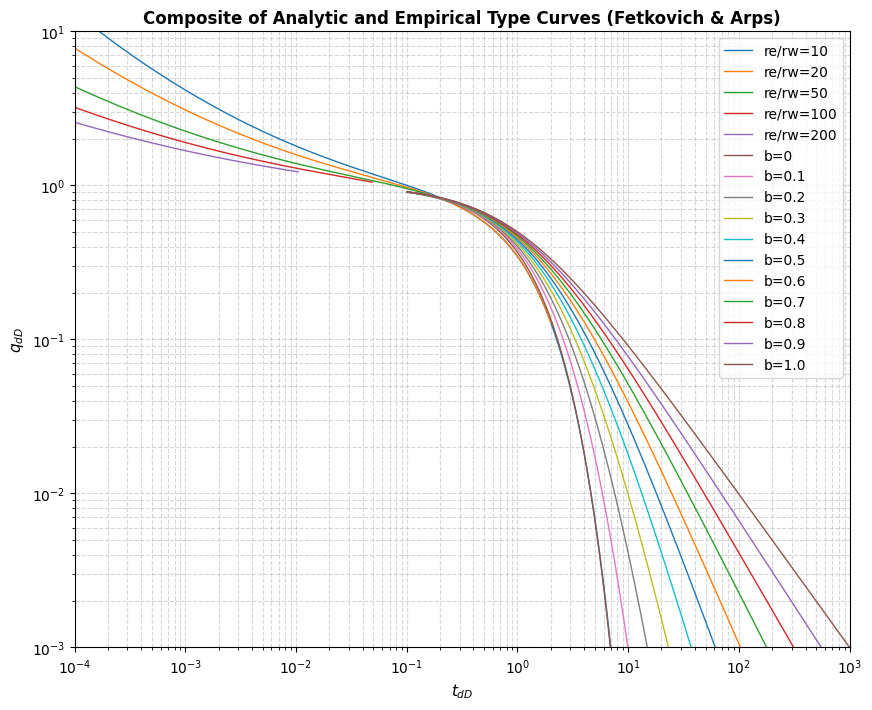

In [ ]:
# Crea el lienzo (fig) y el espacio para dibujar (ax)
fig, ax = plt.subplots(figsize=(10, 8))

# --- CURVAS DE FETKOVICH ---
a,b_1,c,d = -0.00159, 0.06517, 7.22390, 1.81387
e,f,g,h = 4.89275, 0.71374, 0.000448, 0.03622
i,j,k,l = 6.072758, 0.788941, 5.209117, 0.783041
re_rw_lst = [10,20,50,100,200]#,1000,10000,100000] #np.arange(10,100,20)
#print(re_rw)
for re_rw in re_rw_lst:
  #print(f"re_rw={re_rw}")
  A0 = a+b_1/(1+c*(((np.log(re_rw)-0.5)-d)/e)**2)**f
  A1 = g+h/(1+i*(((np.log(re_rw)-0.5)-j)/k)**2)**l
  tD = np.arange(0.01,1000,0.01)
  tdD = tD/(0.5*((re_rw**2)-1)*(np.log(re_rw)-0.5))
  b = 1*10**(-8)
  qdD = (1+b*tdD)**(-1/b)*np.exp(A1*np.log(tdD)**2-A0)
  ax.plot(tdD, qdD, linestyle='-', linewidth=1, label=f"re/rw={re_rw}")

# ---  ARPS CURVES ---
#b = 0
Di = 1
t = np.arange(0.1, 10000, 0.01)#np.logspace(-1, 3, num=100) #-2,3
q = 1/(np.exp(Di*t))

# Grafica para b=0 (Exponencial)
ax.plot(t, q,  linestyle='-', linewidth=1, label="b=0")

# Graficas para b = 0.1 -> 1.0 (Hiperbólica)
#t = np.logspace(-2, 3, num=100)
b = np.arange(0.1,1.1,0.1)
for i in b:
  q = 1/(1+(i*Di*t))**(1/i)
  ax.plot(t, q, linestyle='-', linewidth=1, label=f"b={i:.1f}")

# --- Axis and Format ---
ax.set_xscale('log')  # <--- Esto activa la escala logarítmica en el eje X
ax.set_yscale('log')  # <--- Esto activa la escala logarítmica en el eje Y
ax.set_ylim(0.001, 10)
ax.set_xlim(0.0001, 1000)

ax.set_title("Composite of Analytic and Empirical Type Curves (Fetkovich & Arps)", fontsize=12, fontweight='bold')
ax.set_xlabel("$t_{dD}$", fontsize=11)
ax.set_ylabel("$q_{dD}$", fontsize=11)

# principal and secondary grid in log scale
ax.grid(True, which="both", ls="--", alpha=0.5)

# show legend
plt.legend()


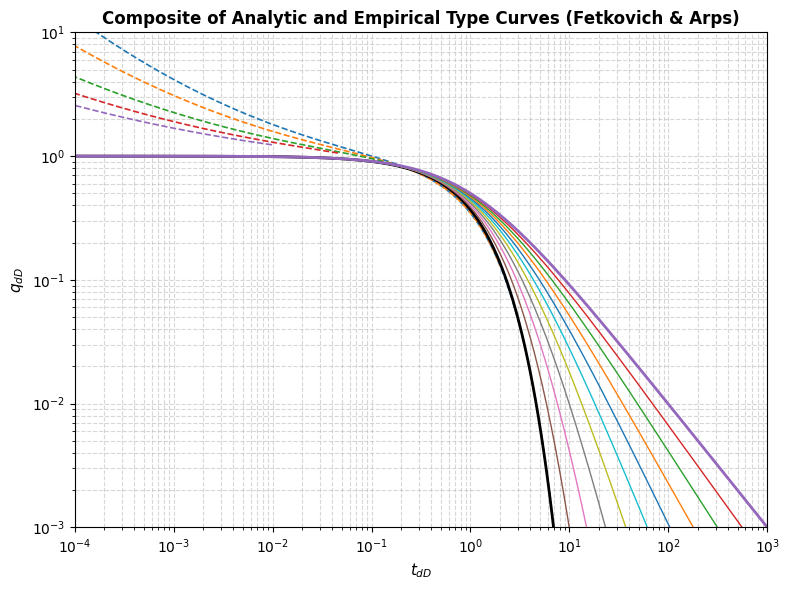

In [14]:
"""
File: dca_type_curves.py
------------------------
This project replicates the classic Decline Curve Analysis (DCA) paper,
combining the analytical transient flow curves (Fetkovich Type Curves)
and empirical production decline curves (Arps).
It helps petroleum engineers forecast production and estimate reservoir behavior.
"""

import matplotlib.pyplot as plt
import numpy as np

def plot_fetkovich_curves(ax):
    """Calculates and plots the transient analytical curves for different re/rw ratios."""
    # Empirical coefficients for Fetkovich analytical curves
    coef_A0 = {'a': -0.00159, 'b': 0.06517, 'c': 7.22390, 'd': 1.81387, 'e': 4.89275, 'f': 0.71374}
    coef_A1 = {'g': 0.000448, 'h': 0.03622, 'i': 6.072758, 'j': 0.788941, 'k': 5.209117, 'l': 0.783041}

    re_rw_list = [10, 20, 50, 100, 200]

    # Logarithmic spacing is ideal for log-log plots to avoid data distortion
    tD = np.logspace(-2, 3, num=500)

    for re_rw in re_rw_list:
        ln_re = np.log(re_rw) - 0.5

        # Solving intermediate polynomial fits
        A0 = coef_A0['a'] + coef_A0['b'] / (1 + coef_A0['c'] * ((ln_re - coef_A0['d']) / coef_A0['e'])**2)**coef_A0['f']
        A1 = coef_A1['g'] + coef_A1['h'] / (1 + coef_A1['i'] * ((ln_re - coef_A1['j']) / coef_A1['k'])**2)**coef_A1['l']

        tdD = tD / (0.5 * ((re_rw**2) - 1) * ln_re)

        # b approaches 0 for pure transient analytical behavior
        b_fetkovich = 1e-8
        qdD = (1 + b_fetkovich * tdD)**(-1 / b_fetkovich) * np.exp(A1 * np.log(tdD)**2 - A0)

        ax.plot(tdD, qdD, linestyle='--', linewidth=1.2, label=f"re/rw = {re_rw}")


def plot_arps_curves(ax):
    """Calculates and plots the empirical Arps decline curves (b from 0 to 1)."""
    Di = 1
    t_arps = np.logspace(-4, 3, num=500)

    # 1. Exponential Decline (b = 0)
    with np.errstate(over='ignore'):
      q_exp = 1 / (np.exp(Di * t_arps))
    ax.plot(t_arps, q_exp, linestyle='-', linewidth=2, color='black', label="b = 0 (Exponential)")

    # 2. Hyperbolic & Harmonic Decline (b from 0.1 to 1.0)
    b_values = np.arange(0.1, 1.1, 0.1)
    for b_val in b_values:
        q_hyp = 1 / (1 + (b_val * Di * t_arps))**(1 / b_val)

        # Formatting: Highlight harmonic curve (b=1.0)
        if np.isclose(b_val, 1.0):
            ax.plot(t_arps, q_hyp, linestyle='-', linewidth=2, label="b = 1.0 (Harmonic)")
        else:
            ax.plot(t_arps, q_hyp, linestyle='-', linewidth=1, label=f"b = {b_val:.1f}")

def setup_plot_style(ax):
    """Applies logarithmic scales, labels, limits, and grid styling."""
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(0.001, 10)
    ax.set_xlim(0.0001, 1000)

    ax.set_title("Composite of Analytic and Empirical Type Curves (Fetkovich & Arps)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("$t_{dD}$", fontsize=11)
    ax.set_ylabel("$q_{dD}$", fontsize=11)

    # Enable both major and minor grid lines for accurate log-scale reading
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # Legend placement outside the plot area
    #ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

def line(ax):
# draw a vertical line, before line -> transient, after line-> depletion
  ax.axvline(
      x=0.25,  # value in x
      color="red",  # Color
      linestyle="--",  # line style (discontinua/guiones)
      linewidth=1.5,  # width
      label="Line")  #, legend

def plot_production_data(ax):
    """
    It simulates and overlays real well production data (q vs t)
    shifted by a 'match point' to align with the type curves.
    """
    # 1. Data Time(days), Rate(bbl/d)
    # hyperbolic decline in rate
    time_days = np.array([1, 2, 5, 10, 20, 30, 50, 100, 180, 250, 360, 500])
    q_bbl_d = np.array([1000, 950, 820, 680, 510, 420, 310, 190, 120, 90, 65, 45])

    # 2. adimentional points
    t_match = 120    # time factor
    q_match = 850    # rate factor

    # 3. Convert data in adimentional values
    t_adimensional = time_days / t_match
    q_adimensional = q_bbl_d / q_match

    # 4. plot the data
    ax.scatter(t_adimensional, q_adimensional,
               color='red', marker='o', s=40, edgecolors='black',
               zorder=5, label="Data (Well X-1)")


def main():
    # Initialize the figure and axes
    fig, ax = plt.subplots(figsize=(8, 6))

    # Generate plot components
    plot_fetkovich_curves(ax)
    plot_arps_curves(ax)
    setup_plot_style(ax)
    #line(ax)
    #plot_production_data(ax)

    # Layout adjustment and rendering
    plt.tight_layout()
    plt.savefig('my_final_project.png', dpi=300, bbox_inches='tight')
    plt.show()

# Standard boilerplate to execute the program
if __name__ == '__main__':
    main()

#**Thank you Code in place 2026!!! Amazing Journey...**